# Wasserstein over Wasserstein for asymmetric Gaussian mixtures

This notebook generates `fig:kantorovich-wow-mixtures`.  A three-component
Gaussian mixture can be viewed either as a collapsed density on the line, or as
a discrete law over Gaussian components equipped with the Bures--Wasserstein
metric.  The example is intentionally asymmetric: a broad central source
component carries most of the mass, whereas the target has two dominant sharp
side components.  Component-level transport moves Gaussian atoms, while the
true one-dimensional $W_2$ geodesic is linear in quantile coordinates and can
split and recombine mass inside the collapsed density.


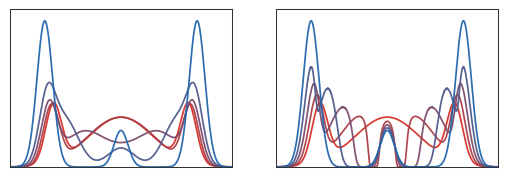

In [1]:

from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import ot

from figure_style import (
    figure_dir, save_pdf, box_axes, setup_matplotlib, interp_color,
)

setup_matplotlib()

OUT = figure_dir("kantorovich-wow-mixtures")
THUMB = NOTEBOOK_DIR / "thumbnails" / "kantorovich-wow-mixtures.png"
THUMB.parent.mkdir(exist_ok=True)

# The broad central source component and the two sharp target side modes
# make the two geometries visibly different at intermediate times.
weights0 = np.array([0.18, 0.64, 0.18])
means0 = np.array([-1.55, 0.00, 1.55])
sigmas0 = np.array([0.18, 0.75, 0.18])
weights1 = np.array([0.45, 0.10, 0.45])
means1 = np.array([-1.75, 0.00, 1.75])
sigmas1 = np.array([0.18, 0.16, 0.18])
xgrid = np.linspace(-2.75, 2.75, 2600)

def gaussian_pdf(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)

def mixture_cdf_values(x, w, m, s):
    return sum(wi * norm.cdf((x - mi) / si) for wi, mi, si in zip(w, m, s))

C = (means0[:, None] - means1[None, :]) ** 2 + (sigmas0[:, None] - sigmas1[None, :]) ** 2
P = ot.emd(weights0, weights1, C)

def component_density(t):
    density = np.zeros_like(xgrid)
    for i in range(len(weights0)):
        for j in range(len(weights1)):
            if P[i, j] > 1e-12:
                m = (1 - t) * means0[i] + t * means1[j]
                s = (1 - t) * sigmas0[i] + t * sigmas1[j]
                density += P[i, j] * gaussian_pdf(xgrid, m, s)
    return density

u = np.linspace(2e-4, 1 - 2e-4, 14000)
cdf0 = mixture_cdf_values(xgrid, weights0, means0, sigmas0)
cdf1 = mixture_cdf_values(xgrid, weights1, means1, sigmas1)
q0 = np.interp(u, cdf0, xgrid)
q1 = np.interp(u, cdf1, xgrid)

def density_from_quantile(q):
    # If X=Q(U), then rho(Q(u)) = 1 / Q'(u).  This avoids adding KDE blur to
    # the exact one-dimensional Wasserstein geodesic.  The final normalization
    # only compensates for the tiny trimmed quantile tails.
    dq = np.gradient(q, u)
    rho_at_q = 1.0 / np.maximum(dq, 1e-6)
    order = np.argsort(q)
    rho = np.interp(xgrid, q[order], rho_at_q[order], left=0.0, right=0.0)
    mass = np.trapezoid(rho, xgrid)
    return rho / max(mass, 1e-12)

def collapsed_density(t):
    return density_from_quantile((1 - t) * q0 + t * q1)

times = np.linspace(0, 1, 5)

def draw_panel(ax, mode):
    ymax = 0.0
    for t in times:
        density = component_density(t) if mode == "component" else collapsed_density(t)
        ymax = max(ymax, float(density.max()))
        ax.plot(xgrid, density, color=interp_color(t), lw=1.25, alpha=0.95)
    ax.set_xlim(-2.55, 2.55)
    ax.set_ylim(0, 1.08 * ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)

fig, axs = plt.subplots(1, 2, figsize=(6.3, 2.05))
for ax, mode in zip(axs, ["component", "collapsed"]):
    draw_panel(ax, mode)
    single, single_ax = plt.subplots(figsize=(3.0, 1.8))
    draw_panel(single_ax, mode)
    save_pdf(single, OUT / ("component-level.pdf" if mode == "component" else "collapsed-w2.pdf"), pad_inches=0.035)
    plt.close(single)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.04)
plt.show()
